In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/2021_Sep5_97k_hydrated_tweets.csv")

In [ ]:
# Before moving forward with a dataset:
# Confirm if country is not available
# Confirm if it was filtered on any search phrase
# Confirm if retweets are included, if yes, drop them
# Dropn NANs/impute as appropriate

In [ ]:
df[df.is_retweet == True]

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str


In [ ]:
df.tail()

,favorite_count,source,text,in_reply_to_screen_name,is_retweet,created_at,retweet_count,id_str
78210,0,PostBeyond,b'An online tool used by people in Italy to ma...,NaN,False,Mon Sep 06 04:02:23 +0000 2021,2,b'1434728659336646657'
78211,1,Khoros CX,"b""@seany_boy71 Hi there, it sounds like you're...",seany_boy71,False,Mon Sep 06 04:02:28 +0000 2021,0,b'1434728682350800900'
78212,0,Twitter Web App,b'@TracyBethHoeg REALLY? YOU THINK? GIVEN THER...,TracyBethHoeg,False,Mon Sep 06 04:02:23 +0000 2021,0,b'1434728661777895425'
78213,0,Twitter for iPhone,b'So in an area thats of \xe2\x80\x98major out...,NaN,False,Mon Sep 06 04:02:22 +0000 2021,0,b'1434728656362897420'
78214,0,Twitter for Android,b'@GovAbbott and State Republicans allowed my ...,GovAbbott,False,Mon Sep 06 04:02:16 +0000 2021,0,b'1434728630991691780'


In [ ]:
df.drop(columns=['id_str',"in_reply_to_screen_name","is_retweet"], inplace=True)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count
0,1,Twitter Web App,b'Oregon Police and Firefighters Sue Governor ...,Sun Sep 05 04:03:21 +0000 2021,1
1,0,Twitter for Android,"b'COVID19 | Of 42,766 new cases reported in In...",Sun Sep 05 04:02:18 +0000 2021,0
2,0,Twitter Web App,b'Get a COVID-19 Yellow Card at SM Supermalls ...,Sun Sep 05 04:01:58 +0000 2021,0
3,0,Twitter Web App,b'DONT NOBODY WANNA HEAR WHAT THAT MAN GOT TO ...,Sun Sep 05 04:02:27 +0000 2021,0
4,4,Twitter for Android,"b'#COVID19 | India reports 42,766 new cases in...",Sun Sep 05 04:02:00 +0000 2021,0


In [ ]:
df.isna().sum().sum()

0

In [ ]:
# Function to Clean the Tweet.

import re
def clean_tweet(tweet):
    return ' '.join(re.sub('(\\\\n)|(b\"[^0-9A-Za-z A-Za-z0-9 \t]+)|(b\'[^0-9A-Za-z]+)|(b\"[A-Za-z0-9]+)|(b\'[A-Za-z0-9]+)|(b\'#[A-Za-z0-9]+)|(b\'@[A-Za-z0-9]+)|(\\\\x[A-Za-z0-9]+)|(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)|([RT])', ' ', str(tweet).lower()).split())

# We only want the Text so :

# (@[A-Za-z0-9]+)   : Delete Anything like @hello @Letsupgrade etc
# ([^0-9A-Za-z \t]) : Delete everything other than text,number,space,tabspace
# (\w+:\/\/\S+)     : Delete https://
# ([RT]) : Remove "RT" from the tweet
# \xe2\x80\x9cguaran : Remove such tags
# b'@thedailybeast : Remove such words : SS - check if we can only remove the b' prefix instead of full word
# SS - Check if apostrophe can be retained eg: hadn't currently becomes hadn t

In [ ]:
# Call function to get Clean tweets
df["CleanTweet"] = df['text'].apply(lambda x : clean_tweet(x))
df.tail(20)

,favorite_count,source,text,created_at,retweet_count,CleanTweet
78195,0,dlvr.it,b'Coronavirus live | Govt determined to vaccin...,Mon Sep 06 04:01:03 +0000 2021,0,live govt determined to vaccinate everyone by ...
78196,1,Twitter for iPhone,"b'@CbusSisCities Sister City of Ahmedabad, Ind...",Mon Sep 06 04:01:01 +0000 2021,0,cbussiscities sister city of ahmedabad india c...
78197,0,Odd_app,"b'In the year 2020, it\xe2\x80\x99s about time...",Mon Sep 06 04:00:45 +0000 2021,0,the year 2020 it about time for the federal le...
78198,0,Twitter for iPhone,b'A Florida teen who was hospitalized with Cov...,Mon Sep 06 04:01:59 +0000 2021,0,florida teen who was hospitalized with covid 1...
78199,1,Twitter for Android,"b'Because they aren\'t ""Pro Life "" they\'re Pr...",Mon Sep 06 04:02:09 +0000 2021,0,they aren t pro life they re pro fetus after t...
78200,0,Twitter for iPhone,"b""Check out The Dude \xe2\x9c\x8c\xef\xb8\x8f'...",Mon Sep 06 04:01:55 +0000 2021,0,out the dude s video tiktok covidiots covid19 ...
78201,1,Twitter Web App,b'@GregAbbott_TX Houston Public Media\n@Housto...,Mon Sep 06 04:01:30 +0000 2021,0,gregabbott tx houston public media sep 3 texas...
78202,0,Twitter for iPhone,b'\xe2\x80\x9cBernier\xe2\x80\x99s death was t...,Mon Sep 06 04:01:57 +0000 2021,0,xe2 death was the third this month among conse...
78203,0,Twitter Web App,b'Pros of QR-Code\n\xf0\x9f\x9a\xa9No transact...,Mon Sep 06 04:02:24 +0000 2021,0,of qr code transaction fee convenient and easi...
78204,0,Twitter for Android,b'Fully vaccinated and hospitalized. Everyth...,Mon Sep 06 04:02:15 +0000 2021,0,vaccinated and hospitalized everything governm...


In [ ]:
df[df.CleanTweet.eq("")]

,favorite_count,source,text,created_at,retweet_count,CleanTweet
44,0,Twitter for iPhone,b'Lunacy https://t.co/aMcfbSSgIK',Sun Sep 05 04:01:58 +0000 2021,0,
251,0,Twitter for iPhone,b'what https://t.co/aJUujhAWmd',Sun Sep 05 04:06:52 +0000 2021,0,
505,0,Twitter for iPhone,b'Damn https://t.co/L7yQD0dzYh',Sun Sep 05 04:12:15 +0000 2021,0,
529,0,Twitter Web App,b'help https://t.co/tv6QOXov1x',Sun Sep 05 04:11:54 +0000 2021,0,
565,0,Twitter for Android,b'Hays https://t.co/c3zb9EO1kJ',Sun Sep 05 04:13:11 +0000 2021,0,
...,...,...,...,...,...,...
77881,0,Twitter for Android,b'Good https://t.co/Nu5VbzOc2E',Mon Sep 06 03:57:46 +0000 2021,0,
77970,0,Twitter Web App,b'Agree https://t.co/RBYNXIfnLa',Mon Sep 06 03:59:37 +0000 2021,0,
78120,0,Twitter for iPhone,b'what https://t.co/WOr8Tvv69s',Mon Sep 06 04:01:38 +0000 2021,0,
78161,0,Twitter for iPad,b'Politics\xe2\x80\xa6. https://t.co/w4KQ9LpDHS',Mon Sep 06 04:01:19 +0000 2021,0,


In [ ]:
df.drop(df.index[df.CleanTweet.eq("")], inplace=True)

In [ ]:
# Function to analyze Sentiment using TextBlob

from textblob import TextBlob
def analyze_sentiment(tweet):
    analysis = TextBlob(tweet)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

In [ ]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
def prepCloud(Topic_text,Topic):
    Topic = str(Topic).lower()
    Topic=' '.join(re.sub('([^0-9A-Za-z \t])', ' ', Topic).split())
    Topic = re.split("\s+",str(Topic))
    stopwords = set(STOPWORDS)
    stopwords.update(Topic) ### Add our topic in Stopwords, so it doesnt appear in wordClous
    ###
    text_new = " ".join([txt for txt in Topic_text.split() if txt not in stopwords])
    return text_new

In [ ]:
# Call function to get the Sentiments

df["Sentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment
0,1,Twitter Web App,b'Oregon Police and Firefighters Sue Governor ...,Sun Sep 05 04:03:21 +0000 2021,1,police and firefighters sue governor over covi...,Neutral
1,0,Twitter for Android,"b'COVID19 | Of 42,766 new cases reported in In...",Sun Sep 05 04:02:18 +0000 2021,0,of 42 766 new cases reported in india in the l...,Positive
2,0,Twitter Web App,b'Get a COVID-19 Yellow Card at SM Supermalls ...,Sun Sep 05 04:01:58 +0000 2021,0,a covid 19 yellow card at sm supermalls in 10 ...,Positive
3,0,Twitter Web App,b'DONT NOBODY WANNA HEAR WHAT THAT MAN GOT TO ...,Sun Sep 05 04:02:27 +0000 2021,0,nobody wanna hear what that man got to say abo...,Neutral
4,4,Twitter for Android,"b'#COVID19 | India reports 42,766 new cases in...",Sun Sep 05 04:02:00 +0000 2021,0,covid19 india reports 42 766 new cases in the ...,Positive


In [ ]:
len(df)

77410

In [ ]:
# Check Summary of Random Record
n = 53000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet:\n",df['Sentiment'][n])

Original tweet:
 b'The COVID-19 crisis in Florida continues to spin wildly out of control. https://t.co/0KfXT3udkM via @HuffPostPol'

Clean tweet:
 covid 19 crisis in florida continues to spin wildly out of control via

Sentiment of the tweet:
 Positive


In [ ]:
# Overall Summary

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["Sentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["Sentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["Sentiment"]=="Neutral"])))

Total Tweets Extracted Are 77410
Total Positive Tweets are : 26964
Total Negative Tweets are : 12948
Total Neutral Tweets are : 37498


In [ ]:
df["Sentiment"].value_counts()

Neutral     37498
Positive    26964
Negative    12948
Name: Sentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

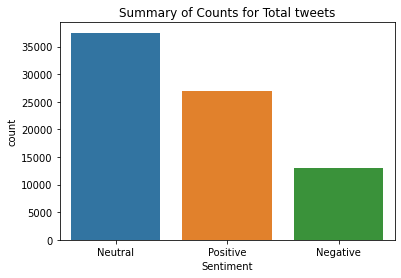

In [ ]:
sns.countplot(df["Sentiment"])
plt.title("Summary of Counts for Total tweets")

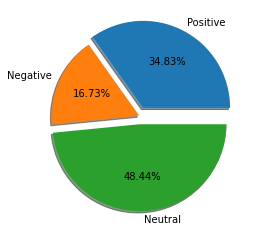

In [ ]:
a=len(df[df["Sentiment"]=="Positive"])
b=len(df[df["Sentiment"]=="Negative"])
c=len(df[df["Sentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install vaderSentiment

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 125 kB 4.1 MB/s 


In [ ]:
# Function to analyze Sentiment using Vader

#from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

def analyze_sentiment_vader(tweet):
    analyzer = SentimentIntensityAnalyzer()
    analysis = analyzer.polarity_scores(tweet)
    # decide sentiment as positive, negative and neutral
    if analysis['compound'] >= 0.05 :
        return "Positive"
    elif analysis['compound'] <= - 0.05 :
        return "Negative"
    else :
        return "Neutral"

In [ ]:
# Call function to get the Sentiments using Vader

df["VaderSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_vader(x))

In [ ]:
df.tail(15)

In [ ]:
df.head()

In [ ]:
df.to_csv("2020_Sep6_TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Vader
n = 53000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Vader:\n",df['VaderSentiment'][n])

Original tweet:
 b'The COVID-19 crisis in Florida continues to spin wildly out of control. https://t.co/0KfXT3udkM via @HuffPostPol'

Clean tweet:
 covid 19 crisis in florida continues to spin wildly out of control via

Sentiment of the tweet using Vader:
 Negative


In [ ]:
# Overall Summary for Vader

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["VaderSentiment"]=="Positive"])))
print("Total Negative Tweets are : {}".format(len(df[df["VaderSentiment"]=="Negative"])))
print("Total Neutral Tweets are : {}".format(len(df[df["VaderSentiment"]=="Neutral"])))

Total Tweets Extracted Are 77410
Total Positive Tweets are : 24082
Total Negative Tweets are : 22270
Total Neutral Tweets are : 31058


In [ ]:
df["VaderSentiment"].value_counts()

Neutral     31058
Positive    24082
Negative    22270
Name: VaderSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

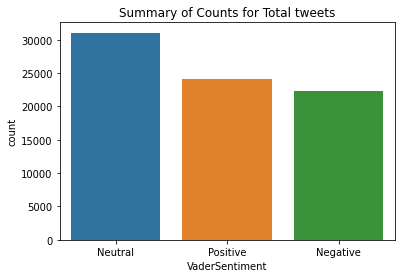

In [ ]:
sns.countplot(df["VaderSentiment"])
plt.title("Summary of Counts for Total tweets")

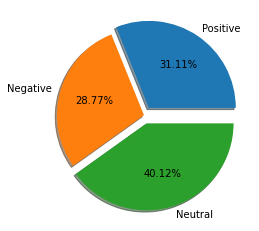

In [ ]:

a=len(df[df["VaderSentiment"]=="Positive"])
b=len(df[df["VaderSentiment"]=="Negative"])
c=len(df[df["VaderSentiment"]=="Neutral"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

In [ ]:
pip install flair

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 401 kB 4.1 MB/s 
     |████████████████████████████████| 1.2 MB 48.7 MB/s 
     |████████████████████████████████| 788 kB 42.8 MB/s 
     |████████████████████████████████| 1.6 MB 43.1 MB/s 
     |████████████████████████████████| 53 kB 1.9 MB/s 
     |████████████████████████████████| 19.7 MB 1.3 MB/s 
     |████████████████████████████████| 4.7 MB 38.9 MB/s 
     |████████████████████████████████| 120 kB 65.1 MB/s 
     |████████████████████████████████| 46 kB 3.8 MB/s 
     |████████████████████████████████| 981 kB 47.9 MB/s 
     |████████████████████████████████| 200 kB 59.0 MB/s 
     |████████████████████████████████| 62 kB 1.6 MB/s 
     |████████████████████████████████| 6.6 MB 35.6 MB/s 
  Created wheel for mpld3: filename=mpld3-0.3-py3-none-any.whl size=116702 sha256=af593a2d586aa1e6c0e00eb8b24846a55de5241a9bf90e83fdd1407de0af92bb
  Store

In [ ]:
# Function to analyze Sentiment using Flair

from flair.models import TextClassifier
from flair.data import Sentence
classifier = TextClassifier.load('en-sentiment')
def analyze_sentiment_flair(tweet):
    sentence = Sentence(tweet)
    classifier.predict(sentence)
    #if(sentence.labels[0].value == 'POSITIVE'):
    #    return 'Positive'
    #else:
    #    return 'Negative'
    return sentence.labels[0].value

2022-09-14 09:50:37,105 https://nlp.informatik.hu-berlin.de/resources/models/sentiment-curated-distilbert/sentiment-en-mix-distillbert_4.pt not found in cache, downloading to /tmp/tmpuy7dvldr


100%|██████████| 265512723/265512723 [00:13<00:00, 19920071.45B/s]

2022-09-14 09:50:50,846 copying /tmp/tmpuy7dvldr to cache at /root/.flair/models/sentiment-en-mix-distillbert_4.pt


2022-09-14 09:50:51,606 removing temp file /tmp/tmpuy7dvldr
2022-09-14 09:50:51,665 loading file /root/.flair/models/sentiment-en-mix-distillbert_4.pt


In [ ]:
# Call function to get the Sentiments using Flair

df["FlairSentiment"] = df["CleanTweet"].apply(lambda x : analyze_sentiment_flair(x))
df.head(5)

,favorite_count,source,text,created_at,retweet_count,CleanTweet,Sentiment,VaderSentiment,FlairSentiment
0,1,Twitter Web App,b'Oregon Police and Firefighters Sue Governor ...,Sun Sep 05 04:03:21 +0000 2021,1,police and firefighters sue governor over covi...,Neutral,Neutral,NEGATIVE
1,0,Twitter for Android,"b'COVID19 | Of 42,766 new cases reported in In...",Sun Sep 05 04:02:18 +0000 2021,0,of 42 766 new cases reported in india in the l...,Positive,Positive,POSITIVE
2,0,Twitter Web App,b'Get a COVID-19 Yellow Card at SM Supermalls ...,Sun Sep 05 04:01:58 +0000 2021,0,a covid 19 yellow card at sm supermalls in 10 ...,Positive,Positive,NEGATIVE
3,0,Twitter Web App,b'DONT NOBODY WANNA HEAR WHAT THAT MAN GOT TO ...,Sun Sep 05 04:02:27 +0000 2021,0,nobody wanna hear what that man got to say abo...,Neutral,Positive,NEGATIVE
4,4,Twitter for Android,"b'#COVID19 | India reports 42,766 new cases in...",Sun Sep 05 04:02:00 +0000 2021,0,covid19 india reports 42 766 new cases in the ...,Positive,Neutral,NEGATIVE


In [ ]:
df.rename(columns={'Sentiment': 'TextBlobSentiment'},inplace=True)

In [ ]:
df.head()

,favorite_count,source,text,created_at,retweet_count,CleanTweet,TextBlobSentiment,VaderSentiment,FlairSentiment
0,1,Twitter Web App,b'Oregon Police and Firefighters Sue Governor ...,Sun Sep 05 04:03:21 +0000 2021,1,police and firefighters sue governor over covi...,Neutral,Neutral,NEGATIVE
1,0,Twitter for Android,"b'COVID19 | Of 42,766 new cases reported in In...",Sun Sep 05 04:02:18 +0000 2021,0,of 42 766 new cases reported in india in the l...,Positive,Positive,POSITIVE
2,0,Twitter Web App,b'Get a COVID-19 Yellow Card at SM Supermalls ...,Sun Sep 05 04:01:58 +0000 2021,0,a covid 19 yellow card at sm supermalls in 10 ...,Positive,Positive,NEGATIVE
3,0,Twitter Web App,b'DONT NOBODY WANNA HEAR WHAT THAT MAN GOT TO ...,Sun Sep 05 04:02:27 +0000 2021,0,nobody wanna hear what that man got to say abo...,Neutral,Positive,NEGATIVE
4,4,Twitter for Android,"b'#COVID19 | India reports 42,766 new cases in...",Sun Sep 05 04:02:00 +0000 2021,0,covid19 india reports 42 766 new cases in the ...,Positive,Neutral,NEGATIVE


In [ ]:
df.to_csv("2021_Sep5_TextBlob-Vader-Flair-TweetSentimentDataset.csv",index=False)

In [ ]:
# Check Summary of Random Record for Flair
n = 53000
print("Original tweet:\n",df['text'][n])
print()
print("Clean tweet:\n",df['CleanTweet'][n])
print()
print("Sentiment of the tweet using Flair:\n",df['FlairSentiment'][n])

Original tweet:
 b'The COVID-19 crisis in Florida continues to spin wildly out of control. https://t.co/0KfXT3udkM via @HuffPostPol'

Clean tweet:
 covid 19 crisis in florida continues to spin wildly out of control via

Sentiment of the tweet using Flair:
 NEGATIVE


In [ ]:
# Overall Summary for Flair

print("Total Tweets Extracted Are {}".format(len(df.text)))
print("Total Positive Tweets are : {}".format(len(df[df["FlairSentiment"]=="POSITIVE"])))
print("Total Negative Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEGATIVE"])))
print("Total Neutral Tweets are : {}".format(len(df[df["FlairSentiment"]=="NEUTRAL"])))

Total Tweets Extracted Are 77410
Total Positive Tweets are : 28171
Total Negative Tweets are : 49239
Total Neutral Tweets are : 0


In [ ]:
df["FlairSentiment"].value_counts()

NEGATIVE    49239
POSITIVE    28171
Name: FlairSentiment, dtype: int64

/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


Text(0.5, 1.0, 'Summary of Counts for Total tweets')

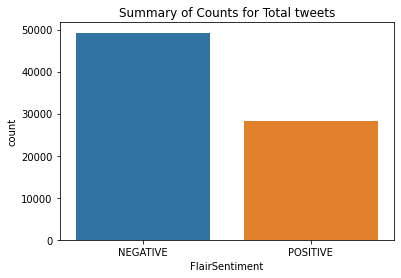

In [ ]:
sns.countplot(df["FlairSentiment"])
plt.title("Summary of Counts for Total tweets")

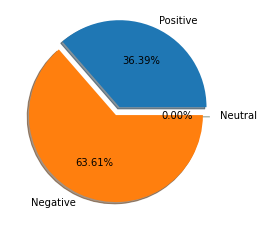

In [ ]:
# Piechart 

a=len(df[df["FlairSentiment"]=="POSITIVE"])
b=len(df[df["FlairSentiment"]=="NEGATIVE"])
c=len(df[df["FlairSentiment"]=="NEUTRAL"])
d=np.array([a,b,c])
explode = (0.1, 0.0, 0.1)
plt.pie(d,shadow=True,explode=explode,labels=["Positive","Negative","Neutral"],autopct='%1.2f%%');

There are 6344752 words in the combination of all review.


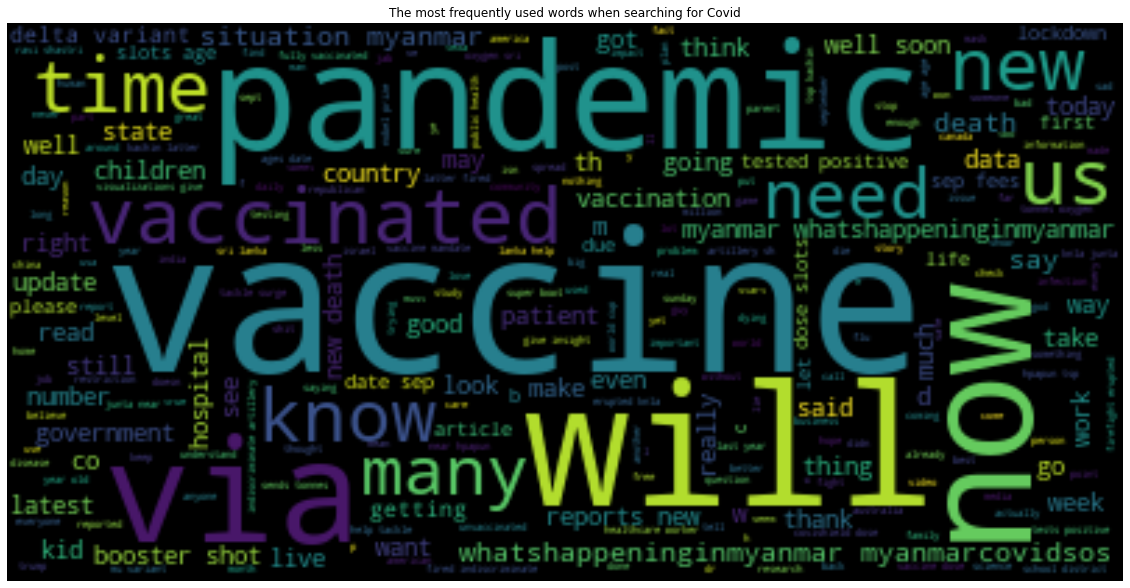

In [ ]:
# Combine all reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text = " ".join(review for review in df.CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_newALL = prepCloud(text,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_newALL)

# Display the generated image:
# the matplotlib way:


plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words when searching for {}".format("Covid"),)
plt.axis("off")
plt.show()

There are 6344752 words in the combination of all review.


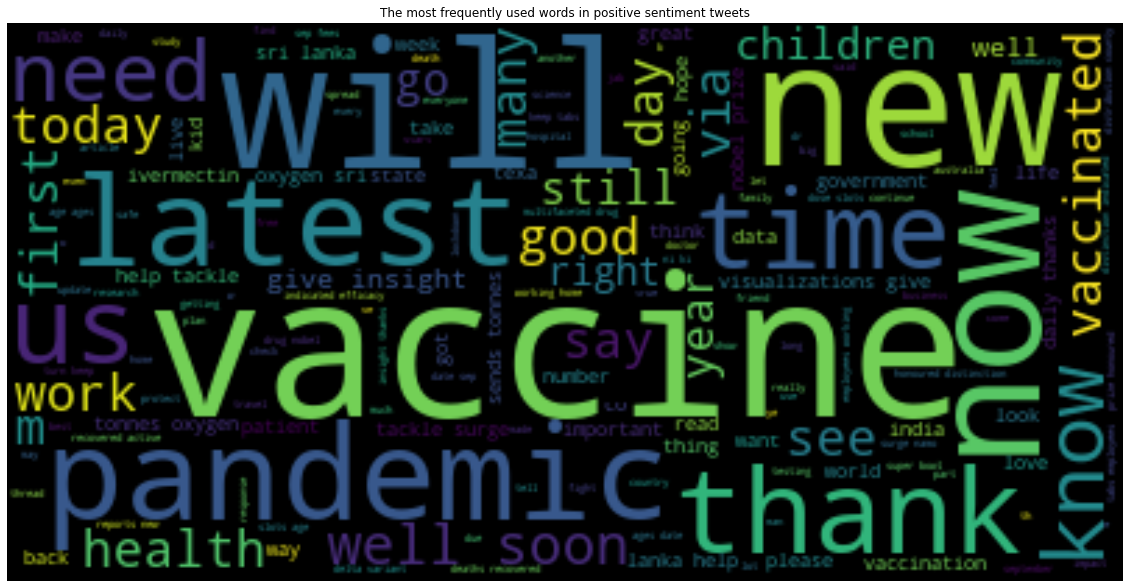

In [ ]:
# Combine POSITIVE reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_positive = " ".join(review for review in df[df["FlairSentiment"]=="POSITIVE"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_positive = prepCloud(text_positive,Topic)


# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_positive)


plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in positive sentiment tweets")
plt.axis("off")
plt.show()

There are 6344752 words in the combination of all review.


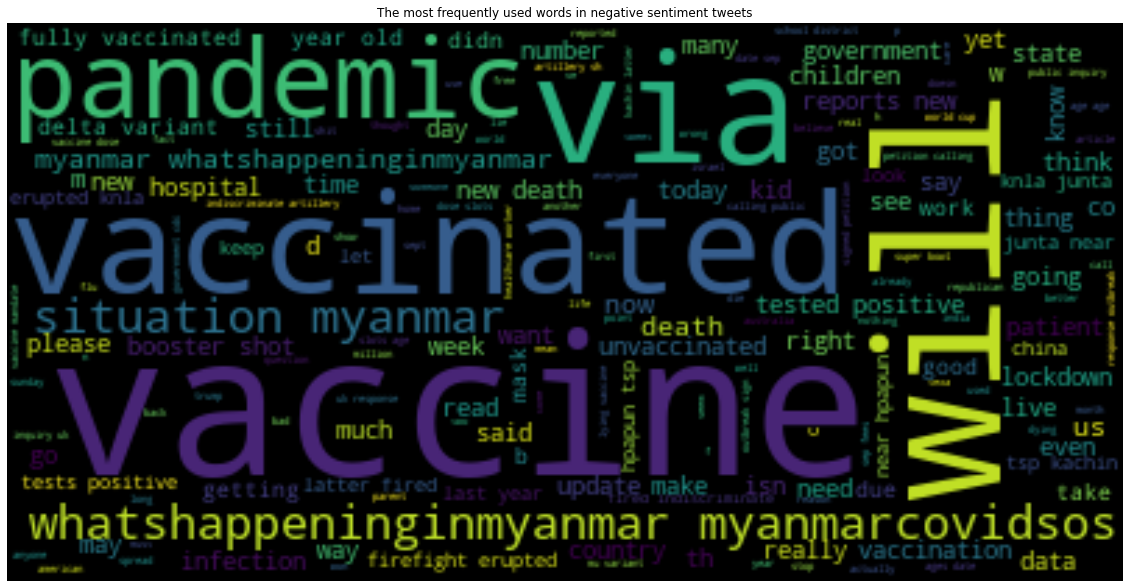

In [ ]:
# Combine Negative reviews into one big text and create a Cloud to see which Words are most common in these Tweets.

text_negative = " ".join(review for review in df[df["FlairSentiment"]=="NEGATIVE"].CleanTweet)
print ("There are {} words in the combination of all review.".format(len(text)))


# Create stopword list:
stopwords = set(STOPWORDS)
Topic= "corona covid covid-19 covid19 coronavirus virus amp people case cases xe2 one don t re s c u xf0"
text_new_negative = prepCloud(text_negative,Topic)

# Generate a word cloud image
wordcloud = WordCloud(stopwords=stopwords,max_words=800,max_font_size=70).generate(text_new_negative)

plt.figure(figsize=(20,20))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title("The most frequently used words in negative sentiment tweets")
plt.axis("off")
plt.show()